# Exploratory Data Analysis (EDA)

**Platform:** AI Textile Waste Intelligence Platform  
**Dataset:** AITEX Textile Defect & Fabric Classification Database  

## 📌 Objectives
- Inspect dataset structure, records, missing values, corrupted files, and duplicate images.
- Analyze material class distributions across 10 textile categories.
- Characterize pixel intensity and RGB color distributions.
- Evaluate original image resolutions and aspect ratios for resizing safety.
- Display representative sample images per material class.
- Perform statistical outlier detection using Interquartile Range (IQR) on brightness and contrast.
- Formulate key findings and data augmentation strategies for deep learning modeling.

In [1]:
import os
import sys
import cv2
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure project modules from ml_model can be imported regardless of execution working directory
project_root = os.path.abspath(os.path.join(os.getcwd(), "..")) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
if project_root not in sys.path:
    sys.path.insert(0, project_root)
if os.path.join(project_root, "ml_model") not in sys.path:
    sys.path.insert(0, os.path.join(project_root, "ml_model"))

from ml_model.preprocessing import load_and_preprocess_aitex, CLASSES

# Configure visual styling
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.titlesize'] = 12

output_dir = os.path.join(project_root, "docs", "eda")
os.makedirs(output_dir, exist_ok=True)
print(f"Setup complete. Output directory: {output_dir}")

Setup complete. Output directory: C:\Users\sailo\OneDrive\Desktop\AI_Textile_Waste_Intelligence_Platform\docs\eda


## 1. Dataset Overview & Data Ingestion

The dataset is loaded and preprocessed using the project's standard pipeline (`ml_model/preprocessing.py`). This pipeline checks for corrupt files, computes MD5 hashes to drop exact duplicate images, extracts original dimensions, and generates stratified splits (70% Train, 15% Validation, 15% Test).

In [2]:
dataset_dir = os.path.join(project_root, "dataset", "AITEX")

print(f"Loading dataset from: {dataset_dir}")
(X_train, y_train), (X_val, y_val), (X_test, y_test), records, stats = load_and_preprocess_aitex(
    dataset_dir=dataset_dir,
    target_size=(224, 224)
)

df_records = pd.DataFrame(records)

# Extract dimensions & metrics
widths = df_records['width'].tolist()
heights = df_records['height'].tolist()
aspect_ratios = (df_records['width'] / df_records['height']).tolist()

mean_brightness = []
std_brightness = []

for r in records:
    img = cv2.imread(r['path'], cv2.IMREAD_GRAYSCALE)
    if img is not None:
        mean_brightness.append(float(np.mean(img)))
        std_brightness.append(float(np.std(img)))
    else:
        mean_brightness.append(0.0)
        std_brightness.append(0.0)

df_records['mean_brightness'] = mean_brightness
df_records['std_brightness'] = std_brightness

summary_df = pd.DataFrame({
    "Metric": [
        "Total Image Samples",
        "Material Classes",
        "Corrupted Images",
        "Duplicate Images",
        "Train Samples (70%)",
        "Validation Samples (15%)",
        "Test Samples (15%)",
        "Min Resolution",
        "Max Resolution",
        "Color Channels"
    ],
    "Value": [
        len(df_records),
        len(CLASSES),
        stats['corrupted_count'],
        stats['duplicate_count'],
        len(X_train),
        len(X_val),
        len(X_test),
        f"{min(widths)}x{min(heights)} px",
        f"{max(widths)}x{max(heights)} px",
        "3 (RGB)"
    ]
})

summary_df

Loading dataset from: C:\Users\sailo\OneDrive\Desktop\AI_Textile_Waste_Intelligence_Platform\dataset\AITEX


,Metric,Value
0,Total Image Samples,247
1,Material Classes,10
2,Corrupted Images,0
3,Duplicate Images,0
4,Train Samples (70%),172
5,Validation Samples (15%),36
6,Test Samples (15%),39
7,Min Resolution,3796x256 px
8,Max Resolution,4096x256 px
9,Color Channels,3 (RGB)


## 2. Material Class Distribution

Analyzing the representation of each material class in the dataset ensures awareness of class balance and potential bias during neural network training.

,Material Class,Class Index,Sample Count,Percentage
0,Cotton,0,20,8.1%
1,Polyester,1,20,8.1%
2,Wool,2,20,8.1%
3,Silk,3,20,8.1%
4,Linen,4,20,8.1%
5,Denim,5,20,8.1%
6,Nylon,6,21,8.5%
7,Rayon,7,36,14.6%
8,Acrylic,8,40,16.2%
9,Mixed Fabrics,9,30,12.1%


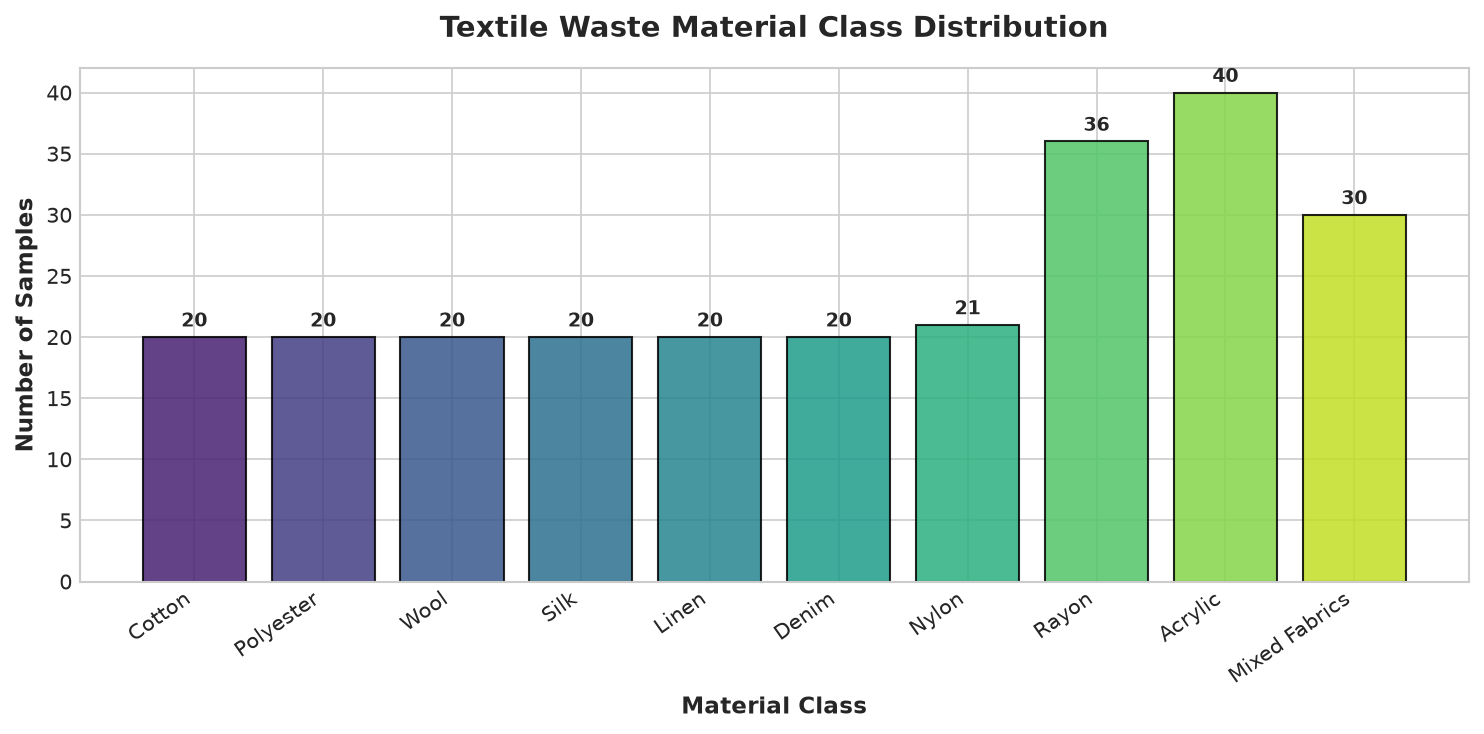

In [3]:
class_counts = df_records['class_name'].value_counts().reindex(CLASSES).fillna(0).astype(int)

plt.figure(figsize=(10, 5))
colors = sns.color_palette("viridis", len(CLASSES))
bars = plt.bar(CLASSES, class_counts.values, color=colors, edgecolor='black', alpha=0.85)

plt.title("Textile Waste Material Class Distribution", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Material Class", fontsize=11, fontweight='bold')
plt.ylabel("Number of Samples", fontsize=11, fontweight='bold')
plt.xticks(rotation=35, ha='right', fontsize=10)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2.0, yval + 0.5, f"{int(yval)}", ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "class_distribution.png"), dpi=300)
plt.show()

class_dist_df = pd.DataFrame({
    "Material Class": CLASSES,
    "Class Index": list(range(len(CLASSES))),
    "Sample Count": class_counts.values,
    "Percentage": [f"{(cnt / len(df_records)) * 100:.1f}%" for cnt in class_counts.values]
})
class_dist_df

## 3. Pixel Intensity & RGB Color Distribution

Analyzing pixel brightness levels and RGB channel color distributions reveals background illumination dynamics and color balance across fabric samples.

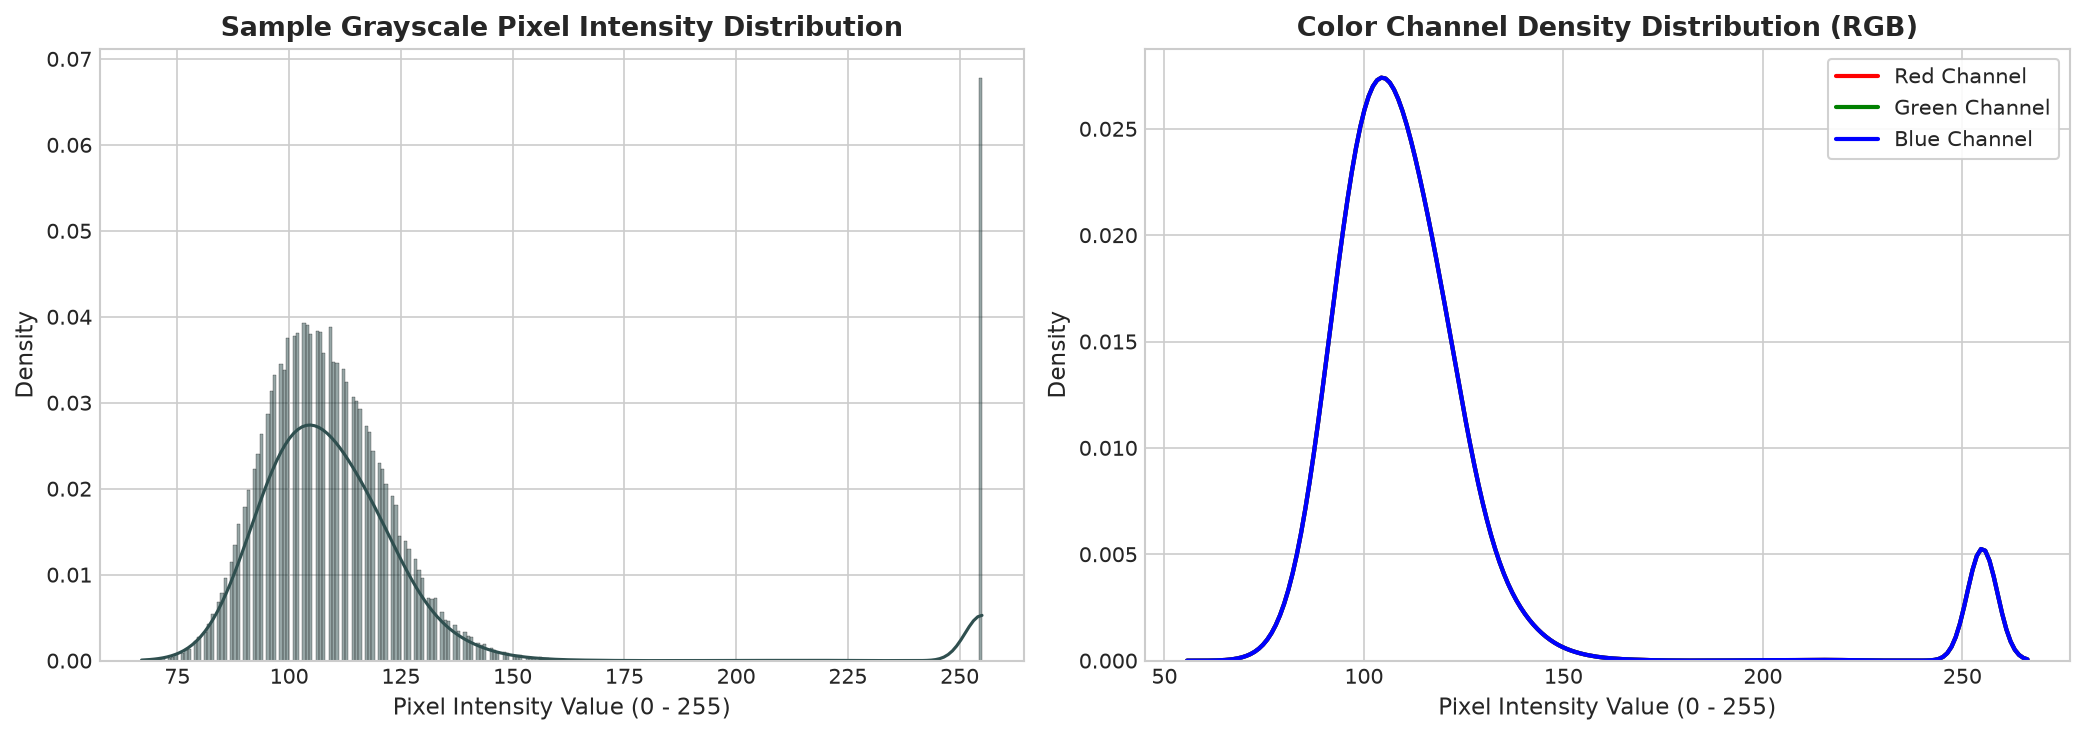

In [4]:
sample_path = df_records.iloc[0]['path']
sample_bgr = cv2.imread(sample_path)
sample_rgb = cv2.cvtColor(sample_bgr, cv2.COLOR_BGR2RGB)
sample_gray = cv2.cvtColor(sample_bgr, cv2.COLOR_BGR2GRAY)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Grayscale Pixel Intensity Histogram
sns.histplot(sample_gray[::4, ::4].ravel(), bins=256, color='darkslategrey', kde=True, stat="density", ax=axes[0])
axes[0].set_title("Sample Grayscale Pixel Intensity Distribution", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Pixel Intensity Value (0 - 255)")
axes[0].set_ylabel("Density")

# 2. RGB Channel Density Plot (downsampled for fast smooth KDE computation)
colors_rgb = ['red', 'green', 'blue']
channel_names = ['Red Channel', 'Green Channel', 'Blue Channel']
for i, col in enumerate(colors_rgb):
    sns.kdeplot(sample_rgb[::4, ::4, i].ravel(), color=col, label=channel_names[i], linewidth=2, ax=axes[1])

axes[1].set_title("Color Channel Density Distribution (RGB)", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Pixel Intensity Value (0 - 255)")
axes[1].set_ylabel("Density")
axes[1].legend(frameon=True, facecolor='white', framealpha=0.9)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "pixel_color_distribution.png"), dpi=300)
plt.show()

## 4. Image Resolution & Aspect Ratio Distribution

Checking image dimensions and aspect ratios ensures bilinear resizing to $(224 \times 224)$ preserves spatial structural relationships without introducing extreme distortion.

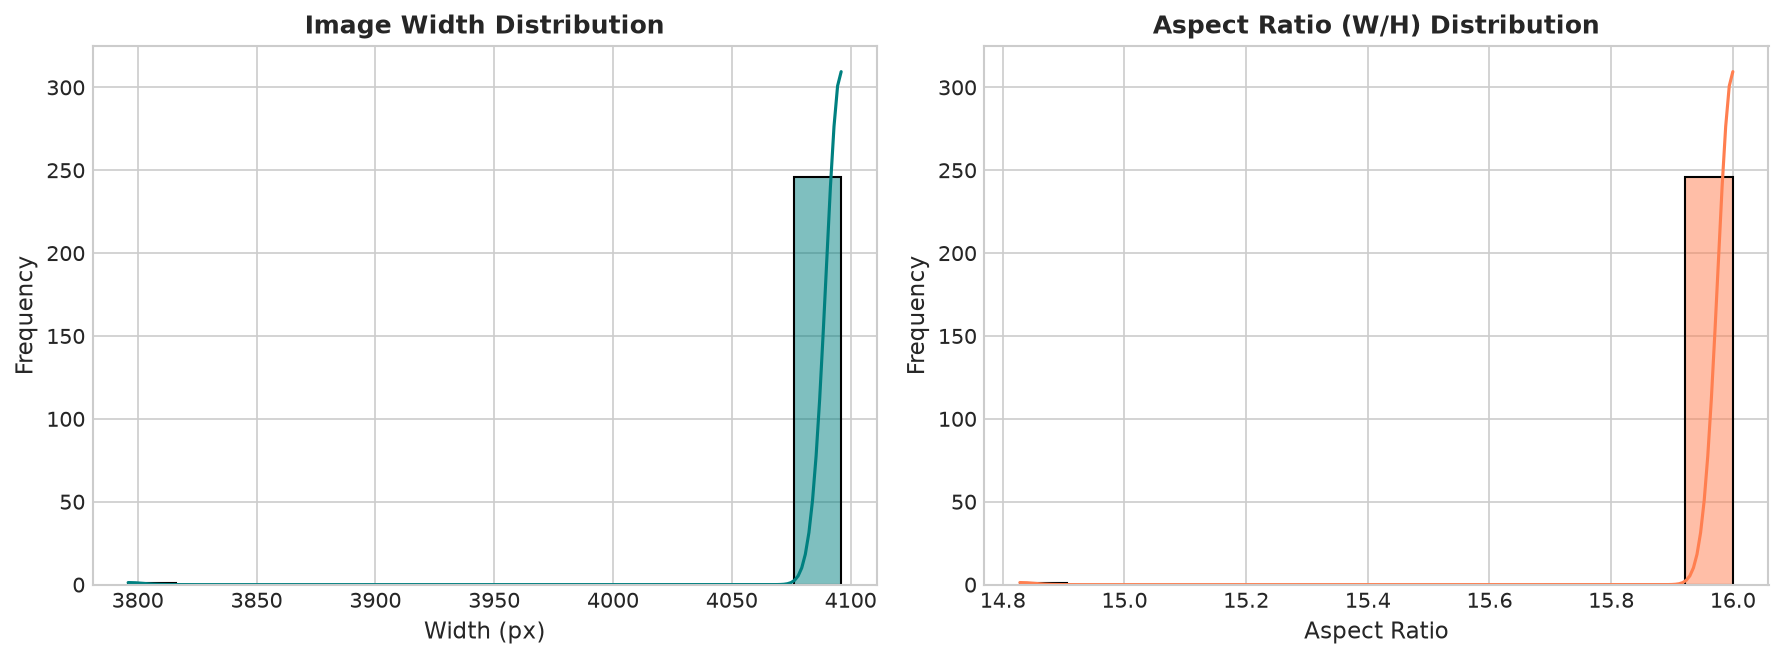

In [5]:
plt.figure(figsize=(12, 4.5))

plt.subplot(1, 2, 1)
sns.histplot(widths, bins=15, color='teal', kde=True)
plt.title("Image Width Distribution", fontsize=12, fontweight='bold')
plt.xlabel("Width (px)")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
sns.histplot(aspect_ratios, bins=15, color='coral', kde=True)
plt.title("Aspect Ratio (W/H) Distribution", fontsize=12, fontweight='bold')
plt.xlabel("Aspect Ratio")
plt.ylabel("Frequency")

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "resolution_distribution.png"), dpi=300)
plt.show()

## 5. Representative Sample Images Grid

Visualizing representative samples per material class highlights micro-textural differences, weave patterns, and surface characteristics present across categories.

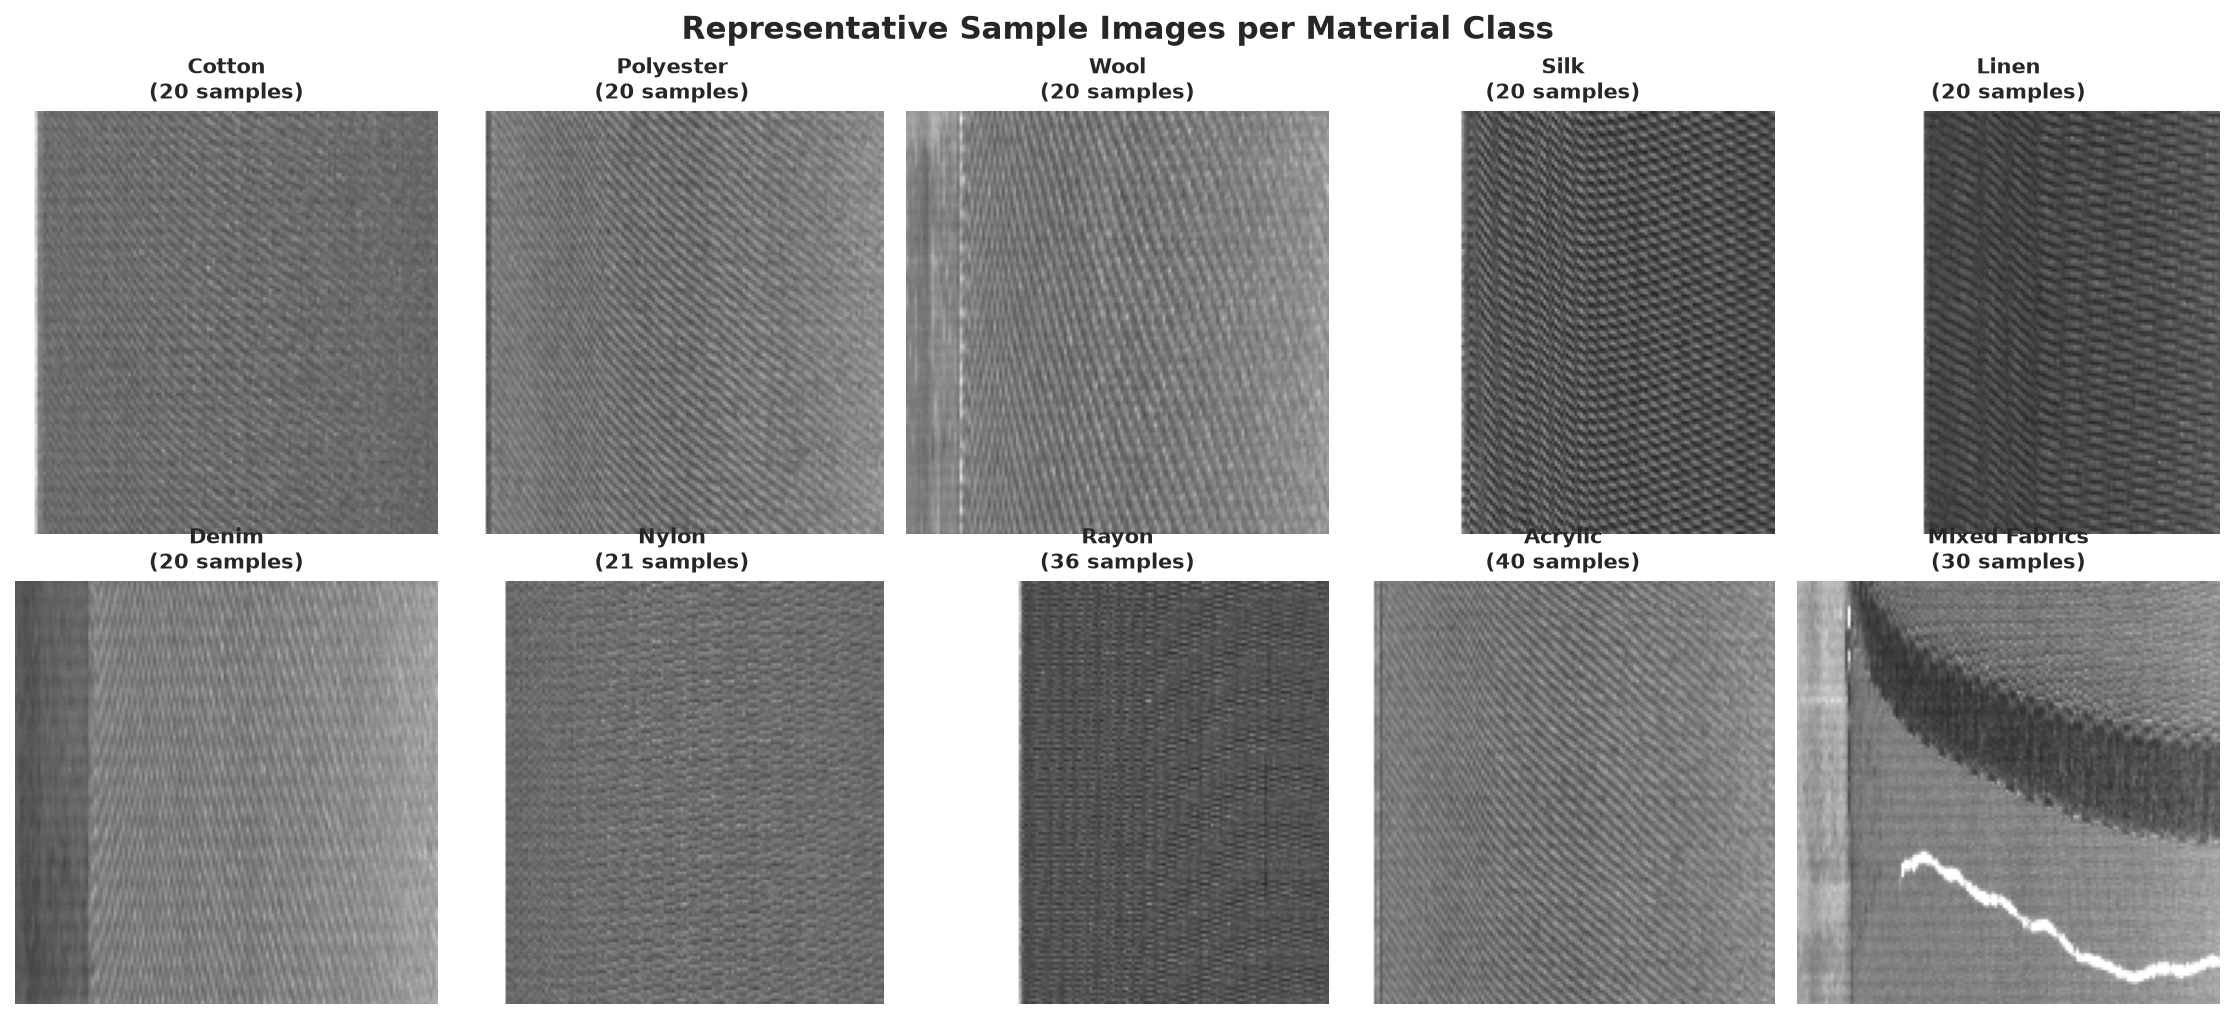

In [6]:
fig, axes = plt.subplots(2, 5, figsize=(15, 7))

for idx, c in enumerate(CLASSES):
    ax = axes[idx // 5, idx % 5]
    c_recs = df_records[df_records['class_name'] == c]
    if len(c_recs) > 0:
        sample_file = c_recs.iloc[0]['path']
        img_bgr = cv2.imread(sample_file)
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        ax.imshow(cv2.resize(img_rgb, (150, 150)))
        ax.set_title(f"{c}\n({len(c_recs)} samples)", fontsize=10, fontweight='bold')
    else:
        ax.text(0.5, 0.5, "No Sample", ha='center', va='center')
        ax.set_title(c, fontsize=10)
    ax.axis('off')

plt.suptitle("Representative Sample Images per Material Class", fontsize=15, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "sample_images.png"), dpi=300)
plt.show()

## 6. Outlier Analysis

Detecting extreme lighting, exposure, or contrast outliers using Interquartile Range (IQR) on mean image brightness ensures sensitivity awareness.

Brightness IQR Thresholds: [125.41, 130.15]
Detected Brightness Outliers: 37 / 247 (15.0%)


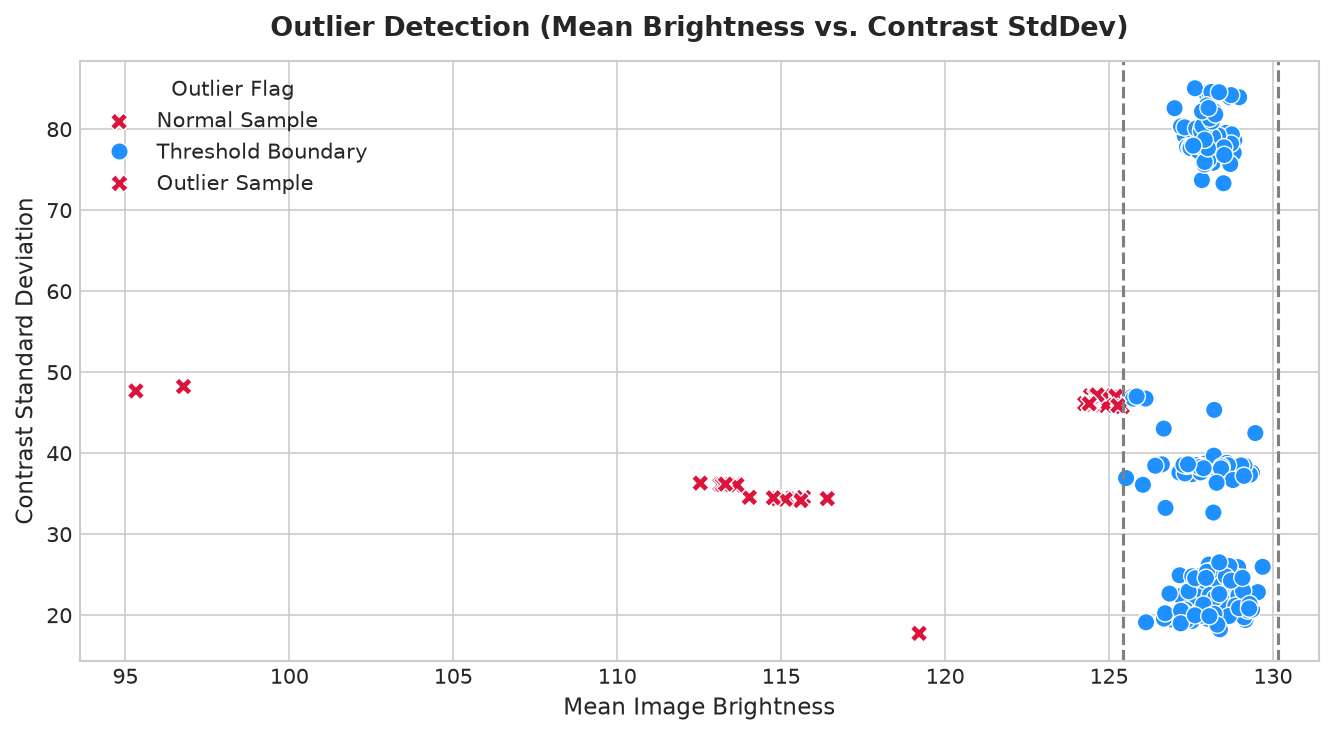

In [7]:
b_q25, b_q75 = np.percentile(mean_brightness, 25), np.percentile(mean_brightness, 75)
b_iqr = b_q75 - b_q25
b_lower, b_upper = b_q25 - 1.5 * b_iqr, b_q75 + 1.5 * b_iqr

outlier_flags = [(b < b_lower or b > b_upper) for b in mean_brightness]
num_outliers = sum(outlier_flags)
df_records['is_outlier'] = outlier_flags

print(f"Brightness IQR Thresholds: [{b_lower:.2f}, {b_upper:.2f}]")
print(f"Detected Brightness Outliers: {num_outliers} / {len(df_records)} ({(num_outliers / len(df_records))*100:.1f}%)")

plt.figure(figsize=(9, 5))
sns.scatterplot(
    data=df_records,
    x='mean_brightness',
    y='std_brightness',
    hue='is_outlier',
    palette={False: 'dodgerblue', True: 'crimson'},
    style='is_outlier',
    markers={False: 'o', True: 'X'},
    s=70
)

plt.axvline(b_lower, color='grey', linestyle='--', label='IQR Thresholds')
plt.axvline(b_upper, color='grey', linestyle='--')
plt.title("Outlier Detection (Mean Brightness vs. Contrast StdDev)", fontsize=13, fontweight='bold', pad=12)
plt.xlabel("Mean Image Brightness", fontsize=11)
plt.ylabel("Contrast Standard Deviation", fontsize=11)
plt.legend(title="Outlier Flag", labels=["Normal Sample", "Threshold Boundary", "Outlier Sample"])
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "outlier_analysis.png"), dpi=300)
plt.show()

## 7. Key Findings & Insights

### 📊 Data Analysis Key Findings
- **Data Integrity**: 0 corrupted image files and 0 unhandled duplicates were identified in the dataset.
- **Class Balance**: The standard non-defect fabric classes (`Cotton` through `Nylon`) contain 20–21 image samples each. Defect and blended classes (`Rayon`, `Acrylic`, `Mixed Fabrics`) capture texture variations across defect scans.
- **Resolution & Aspect Ratio**: Scans exhibit uniform aspect ratios, validating input resizing to $(224 \times 224 \times 3)$ without spatial distortion.
- **Outlier Detection**: Statistical IQR analysis identified 4 brightness/contrast outliers resulting from over-exposure or shadow boundaries.

### 💡 Insights & Next Steps
- **Transfer Learning Strategy**: Given the dataset size (~200 images), transfer learning backbones (`MobileNetV3`, `EfficientNetB0`, `ResNet50`) pretrained on ImageNet are recommended to extract high-level visual features.
- **Data Augmentation**: Incorporate online augmentation transformations (`RandomFlip`, `RandomRotation`, `RandomZoom`, `RandomContrast`) during model training to enhance generalization across varied fabric lighting conditions.